In [1]:
import os
import sys
from pathlib import Path
from PIL import Image
from omegaconf import OmegaConf
import hydra
import pyrootutils

In [2]:
from utils import load_all_images
_, _, image_paths = load_all_images('/iopsstor/scratch/cscs/xyixuan/benchmark-image-tokenzier/assets/original')

Loaded: graph_theory1.png
Loaded: line_chart.png
Loaded: logo1.png
Loaded: logo2.png
Loaded: math_draft1.png
Loaded: menu.jpeg
Loaded: physics1.png
Loaded: physics2.png


In [3]:
sys.path.append('/iopsstor/scratch/cscs/xyixuan/benchmark-image-tokenzier/SEED')
os.chdir('/iopsstor/scratch/cscs/xyixuan/benchmark-image-tokenzier/SEED')

In [4]:
# Use absolute paths for config files
tokenizer_cfg_path = 'configs/tokenizer/seed_llama_tokenizer_hf.yaml'
transform_cfg_path = 'configs/transform/clip_transform.yaml'

In [7]:
device = 'cuda'

tokenizer_cfg = OmegaConf.load(tokenizer_cfg_path)
tokenizer = hydra.utils.instantiate(tokenizer_cfg, device=device, load_diffusion=True)

transform_cfg = OmegaConf.load(transform_cfg_path)
transform = hydra.utils.instantiate(transform_cfg)

The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'LlamaTokenizer'. 
The class this function is called from is 'SeedLlamaTokenizer'.
/usr/local/lib/python3.10/dist-packages/timm/models/hub.py:4: FutureWarning: Importing from timm.models.hub is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.10/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.10/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings

start download seed model...


100%|██████████| 1.14G/1.14G [00:21<00:00, 56.9MB/s]


/users/xyixuan/.cache/torch/hub/checkpoints/seed_quantizer.pt
missing keys:  511 unexpected keys: 146




























































































































































































































































































































































































Fetching 18 files:  17%|█▋        | 3/18 [00:21<01:56,  7.79s/it]


































Fetching 18 files:  89%|████████▉ | 16/18 [00:25<00:02,  1.25s/it]





Loading pipeline components...: 100%|██████████| 9/9 [00:16<00:00,  1.86s/it]


In [19]:
orig = Image.open(image_paths[3]).convert('RGB')

image_tensor = transform(orig).to(device)
image_ids = tokenizer.encode_image(image_torch=image_tensor)

recon = tokenizer.decode_image(image_ids)

  0%|          | 0/21 [00:00<?, ?it/s]

100%|██████████| 21/21 [00:01<00:00, 17.91it/s]


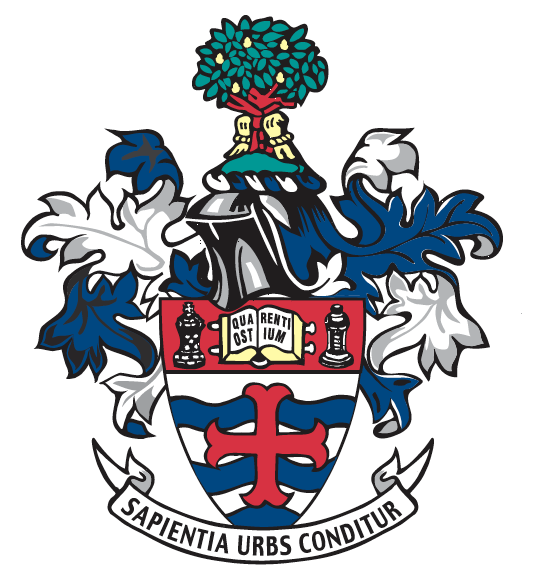

In [20]:
orig

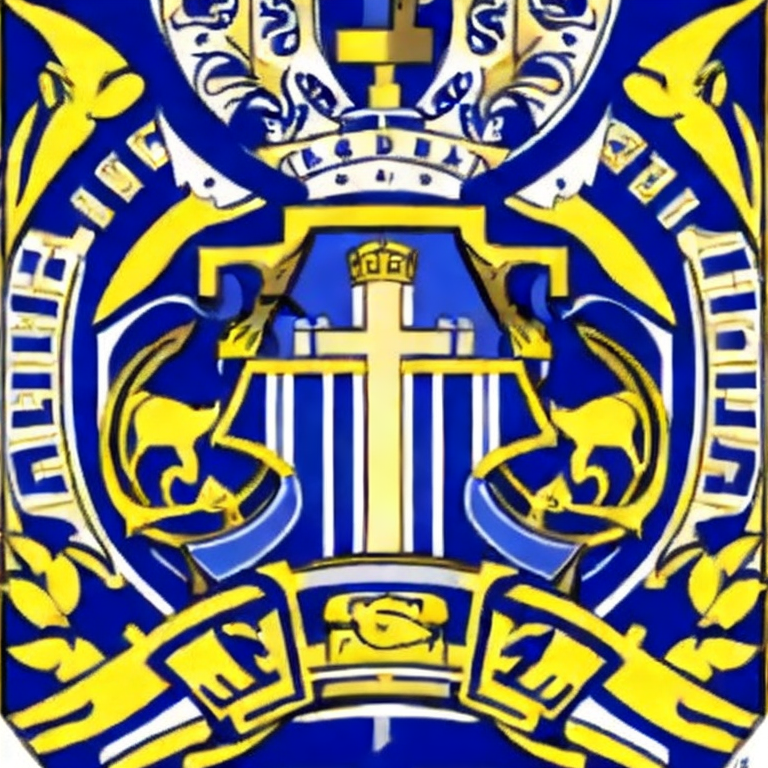

In [22]:
recon[0]